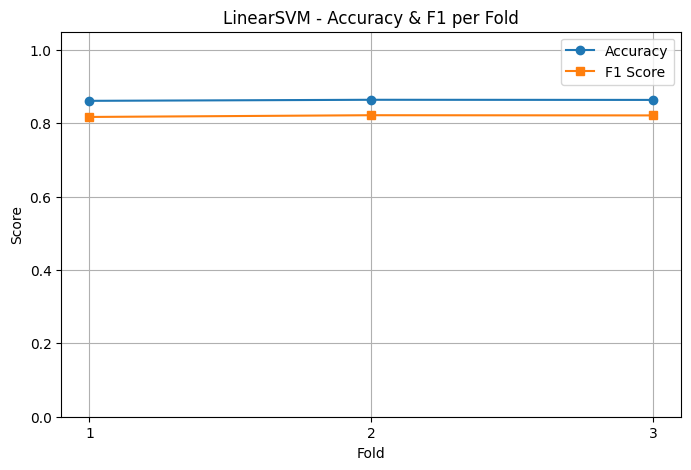

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Path to saved metrics JSON
json_path = "../cicids2017/results/linear_svm_metrics.json"  

with open(json_path, "r") as f:
    metrics_all = json.load(f)

# Check structure
list(metrics_all.keys())

model_name = "LinearSVM"  # replace as needed
folds = metrics_all[model_name]

# Extract metrics
accuracy = [fold['accuracy'] for fold in folds]
f1_score_vals = [fold['f1'] for fold in folds]

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(range(1, len(accuracy)+1), accuracy, marker='o', label='Accuracy')
plt.plot(range(1, len(f1_score_vals)+1), f1_score_vals, marker='s', label='F1 Score')
plt.title(f'{model_name} - Accuracy & F1 per Fold')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.ylim(0,1.05)
plt.xticks(range(1, len(accuracy)+1))
plt.grid(True)
plt.legend()
plt.show()


In [2]:
avg_accuracy = np.mean([fold['accuracy'] for fold in folds])
avg_f1 = np.mean([fold['f1'] for fold in folds])
avg_precision = np.mean([fold['precision'] for fold in folds])
avg_recall = np.mean([fold['recall'] for fold in folds])
avg_roc_auc = np.mean([fold['roc_auc'] for fold in folds if fold['roc_auc'] is not None])

print(f"{model_name} - Average Metrics Across {len(folds)} Folds")
print(f"Accuracy: {avg_accuracy:.4f}")
print(f"F1 Score: {avg_f1:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"ROC AUC: {avg_roc_auc:.4f}")


LinearSVM - Average Metrics Across 3 Folds
Accuracy: 0.8633
F1 Score: 0.8205
Precision: 0.8101
Recall: 0.8633
ROC AUC: 0.7779
